<a href="https://colab.research.google.com/github/dekenfebrianoo/data_visualization/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kagglehub

path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print("Path to dataset files:", path)

os.listdir(path)

100%|██████████| 18.5k/18.5k [00:00<00:00, 20.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tawfikelmetwally/employee-dataset/versions/1


['Employee.csv']

In [2]:
file_path = os.path.join(path, "Employee.csv")

df = pd.read_csv(file_path)

df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [4]:
df.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [5]:
df.duplicated().unique()
#Duplicate yang muncul hanya berisi true and false, jadi tidak saya bersihkan karena true and false memang dibutuhkan buat data di dataset saya

array([False,  True])

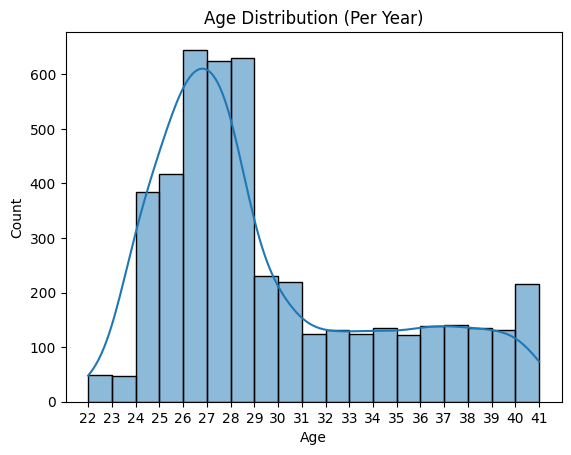

In [6]:
#Skewed Distribution
plt.figure()
sns.histplot(df['Age'], bins=range(df['Age'].min(), df['Age'].max()+1), kde=True)
plt.title("Age Distribution (Per Year)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(False)
plt.xticks(range(df['Age'].min(), df['Age'].max()+1))
plt.show()

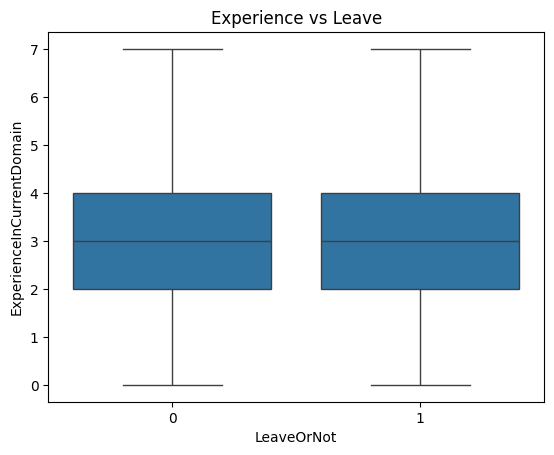

In [7]:
plt.figure()
sns.boxplot(x='LeaveOrNot', y='ExperienceInCurrentDomain', data=df)
plt.title("Experience vs Leave")
plt.show()

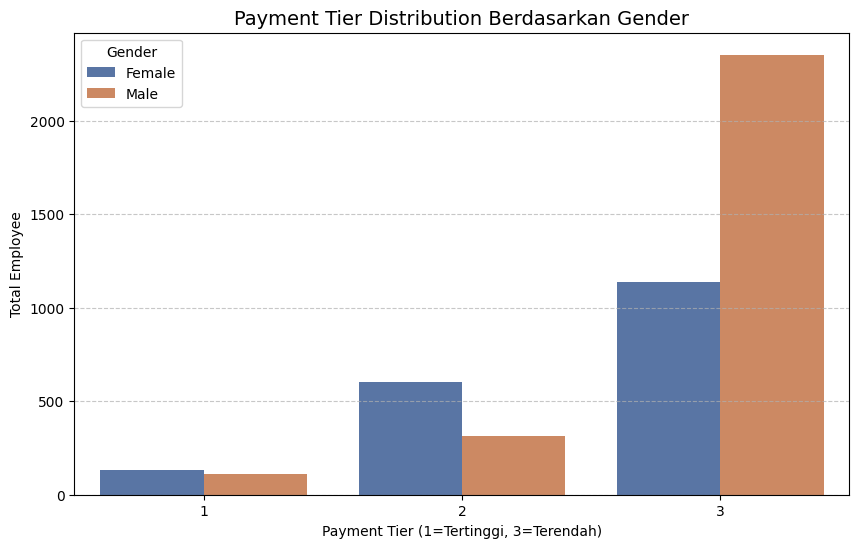

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f"{path}/Employee.csv")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentTier', hue='Gender', palette='deep')

plt.title('Payment Tier Distribution Berdasarkan Gender', fontsize=14)
plt.xlabel('Payment Tier (1=Tertinggi, 3=Terendah)')
plt.ylabel('Total Employee')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1199/1575573435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='Age', palette='Set2')


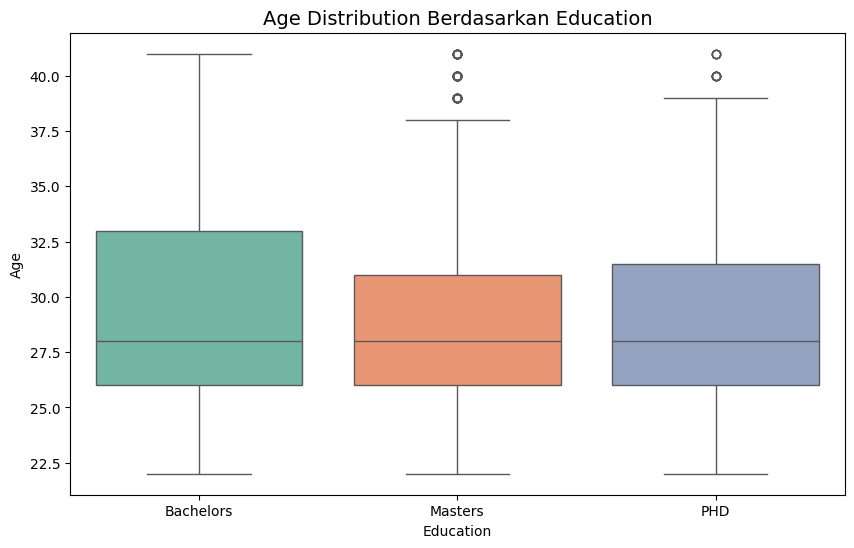

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Education', y='Age', palette='Set2')

plt.title('Age Distribution Berdasarkan Education', fontsize=14)
plt.xlabel('Education')
plt.ylabel('Age')
plt.show()

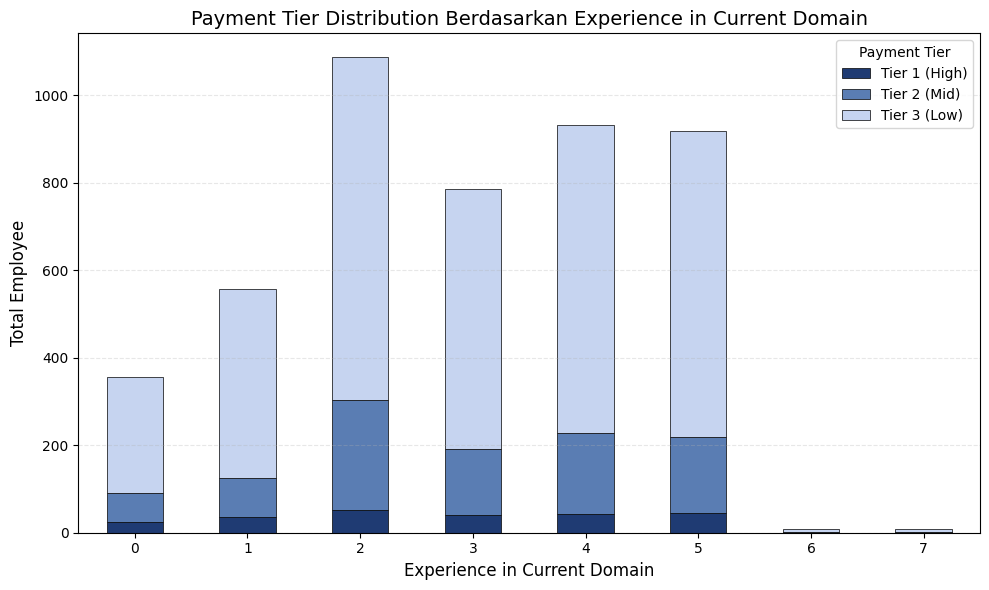

In [10]:
ct = pd.crosstab(df['ExperienceInCurrentDomain'], df['PaymentTier'])

colors = ['#1f3b73', '#5a7db3', '#c6d4f0']

ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Payment Tier Distribution Berdasarkan Experience in Current Domain', fontsize=14)
plt.xlabel('Experience in Current Domain', fontsize=12)
plt.ylabel('Total Employee', fontsize=12)

plt.legend(
    title='Payment Tier',
    labels=['Tier 1 (High)', 'Tier 2 (Mid)', 'Tier 3 (Low)'],
    frameon=True,
    facecolor='white'
)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
from google.colab import files
df.to_csv('datvis_employee.csv', index=False)

files.download('datvis_employee.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>